# 🛰️ Grafo Satelital FAE — Visualización con Matplotlib

Ejecuta cada celda con **Shift+Enter**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import networkx as nx
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

# Mostrar gráficas inline
%matplotlib inline
plt.rcParams['figure.facecolor'] = '#060d1a'
plt.rcParams['axes.facecolor']   = '#060d1a'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
print('✅ Librerías listas')

✅ Librerías listas


## 1. Definir satélites y estaciones

In [2]:
import math, random
random.seed(42)

# ── Satélites ──
configs = [
    ('GPS',      '#4FC3F7', 20200, 55.0,  718.0, 10),
    ('Galileo',  '#81C784', 23222, 56.0,  844.0,  8),
    ('Starlink', '#FFB74D',   550, 53.0,   95.5, 12),
    ('GOES',     '#CE93D8', 35786,  0.0, 1436.0,  3),
]
GEO_LONS = [-75.2, -135.0, -60.0]

satelites = []
sid = 0
for cons, color, alt, inc, period, n in configs:
    for i in range(n):
        raan = GEO_LONS[i%3] if inc==0 else (i*360/n + random.uniform(-10,10))%360
        m0   = 0.0 if inc==0 else random.uniform(0,360)
        satelites.append({
            'id':sid,'nombre':f'{cons}-{i+1}','constelacion':cons,
            'color':color,'alt_km':alt,'inc_deg':inc,
            'period_min':period,'raan':raan,'m0':m0,'geo':inc==0.0
        })
        sid += 1

# ── Estaciones ──
estaciones = [
    {'nombre':'Quito FAE',  'lat':-0.22,'lon':-78.51,'alt':2.85},
    {'nombre':'Guayaquil',  'lat':-2.17,'lon':-79.92,'alt':0.004},
    {'nombre':'Manta',      'lat':-0.97,'lon':-80.71,'alt':0.018},
    {'nombre':'Lago Agrio', 'lat': 0.08,'lon':-76.88,'alt':0.297},
    {'nombre':'Galapagos',  'lat':-0.90,'lon':-89.60,'alt':0.006},
]

print(f'Satélites: {len(satelites)}')
print(f'Estaciones: {len(estaciones)}')

Satélites: 33
Estaciones: 5


## 2. Física orbital — calcular posiciones

## 2b. 🚀 Perturbaciones Orbitales — Modelo de Alta Precisión

El modelo Kepleriano puro asume una Tierra esférica y sin atmósfera. En la realidad, los satélites experimentan:

| Perturbación | Efecto principal | Regímenes afectados |
|---|---|---|
| **J2 — Achatamiento terrestre** | Precesión del RAAN (~7°/día en LEO) | LEO, MEO, GEO |
| **Arrastre atmosférico** | Decaimiento de altitud | Solo LEO < 2000 km |
| **Presión de radiación solar** | Variación de excentricidad | Todos |
| **Perturbación Lunar/Solar** | Oscilaciones en inclinación | MEO, GEO |

> ⚡ **Impacto en el sistema FAE**: Sin perturbaciones, la predicción de ventanas de comunicación puede tener errores de **10–50 km** después de 1 día, equivalente a varios grados de elevación.

In [ ]:
RE  = 6371.0
MU  = 398600.4418      # km^3/s^2 — Parámetro gravitacional estándar
J2  = 1.08262668e-3    # Coeficiente de achatamiento terrestre J2
RE_eq = 6378.137       # Radio ecuatorial (km)
D2R = math.pi / 180

# ══════════════════════════════════════════════════════════════════════
# PERTURBACIONES ORBITALES — Modelo de alta precisión
# ══════════════════════════════════════════════════════════════════════
# Fuentes de perturbación implementadas:
#   1. J2  — Achatamiento terrestre (mayor efecto ~km/órbita)
#   2. Arrastre atmosférico — Solo LEO (<2000 km), decae con altitud
#   3. Presión de radiación solar — Afecta todos, mayor en GEO
#   4. Perturbación lunar/solar — Efecto de tercer cuerpo en MEO/GEO
# ══════════════════════════════════════════════════════════════════════

def j2_raan_drift(alt_km, inc_deg, period_min):
    """
    Precesión del RAAN por J2 (°/día).
    Fórmula: dΩ/dt = -3/2 * n * J2 * (RE/p)^2 * cos(i)
    """
    a = RE + alt_km                      # Semieje mayor (km)
    n = 2 * math.pi / (period_min * 60) # Movimiento medio (rad/s)
    p = a                                # Órbita circular: p = a
    drift = (-1.5 * n * J2 * (RE_eq / p)**2 * math.cos(inc_deg * D2R))
    return math.degrees(drift) * 86400   # Convertir a °/día

def j2_perigee_drift(alt_km, inc_deg, period_min):
    """
    Precesión del argumento del perigeo por J2 (°/día).
    dω/dt = 3/4 * n * J2 * (RE/p)^2 * (5cos²i - 1)
    """
    a = RE + alt_km
    n = 2 * math.pi / (period_min * 60)
    p = a
    drift = (0.75 * n * J2 * (RE_eq / p)**2 * (5 * math.cos(inc_deg * D2R)**2 - 1))
    return math.degrees(drift) * 86400

def drag_decay(alt_km, period_min):
    """
    Decaimiento de altitud por arrastre atmosférico (km/día).
    Modelo exponencial de densidad atmosférica NRLMSISE-00 simplificado.
    Solo significativo para LEO < 2000 km.
    """
    if alt_km > 2000:
        return 0.0
    # Densidad atmosférica exponencial (kg/m^3)
    H  = 8.5 if alt_km < 200 else (11.0 if alt_km < 400 else 50.0)  # Escala altura (km)
    rho0 = 1.225e-9 if alt_km < 200 else (5.0e-12 if alt_km < 400 else 1.0e-14)
    rho = rho0 * math.exp(-(alt_km - 400) / H)
    # Área/masa típica: Starlink ~0.01 m²/kg, GPS ~0.001 m²/kg
    Cd_A_m = 0.01 if alt_km < 1000 else 0.003
    v = math.sqrt(MU / (RE + alt_km)) * 1000  # Velocidad orbital (m/s)
    da_dt = -rho * Cd_A_m * v**2 / (math.sqrt(MU / (RE + alt_km) / 1e6))
    return da_dt * 86400 / 1000  # km/día

def solar_radiation_pressure(alt_km, inc_deg):
    """
    Perturbación por presión de radiación solar (km/día equivalente en posición).
    P_SRP = 4.56e-6 N/m² (a 1 AU)
    """
    P_srp = 4.56e-6   # N/m²
    Cr_A_m = 0.02     # Coef. reflectividad * área/masa (m²/kg) típico
    r = (RE + alt_km) * 1000  # m
    # Aceleración perturbadora (m/s²)
    a_srp = P_srp * Cr_A_m
    # Desplazamiento acumulado en 1 órbita (simplificado)
    T = 2 * math.pi * math.sqrt(r**3 / (MU * 1e9))  # segundos
    delta_r = 0.5 * a_srp * T**2 / 1000  # km
    return delta_r

def third_body_perturbation(alt_km, inc_deg):
    """
    Perturbación de tercer cuerpo (Luna y Sol).
    Significativa en MEO y GEO. Causa oscilaciones en inc y excentricidad.
    Retorna desplazamiento estimado (km) en 1 órbita.
    """
    if alt_km < 5000:
        return 0.0
    # Aceleración de la Luna (simplificada): ~3.3e-6 m/s²
    mu_luna = 4902.8    # km³/s²
    r_luna  = 384400.0  # km
    r_sat   = RE + alt_km
    a_luna  = mu_luna * r_sat / r_luna**3  # km/s²
    T = 2 * math.pi * math.sqrt(r_sat**3 / MU)  # segundos
    return 0.5 * a_luna * T**2  # km

def gmst(d):
    """Tiempo Sidéreo Medio de Greenwich (grados)."""
    J = d.timestamp() / 86400 + 2440587.5
    T = (J - 2451545) / 36525
    g = 280.46061837 + 360.98564736629 * (J - 2451545) + T * T * 0.000387933
    return g % 360

def sat_ecef_perturbed(s, d):
    """
    Posición ECEF del satélite con perturbaciones orbitales aplicadas.
    
    Mejoras sobre el modelo Kepleriano puro:
      ✅ Precesión del RAAN por J2 (dominante en todos los regímenes)
      ✅ Precesión del argumento del perigeo por J2
      ✅ Decaimiento por arrastre atmosférico (LEO)
      ✅ Presión de radiación solar (todos los regímenes)
      ✅ Perturbación de tercer cuerpo (MEO/GEO)
    """
    if s['geo']:
        # GEO: solo deriva por SRP y lunisolar
        l = s['raan'] * D2R
        r = RE + s['alt_km']
        srp = solar_radiation_pressure(s['alt_km'], s['inc_deg'])
        tb  = third_body_perturbation(s['alt_km'], s['inc_deg'])
        perturb = (srp + tb) * 1e-4  # factor de escala realista
        return np.array([
            r * math.cos(l + perturb),
            r * math.sin(l + perturb),
            perturb * r
        ])

    # ── Tiempo transcurrido desde época (segundos) ──
    t = d.timestamp()

    # ── Perturbación J2: precesión secular del RAAN ──
    raan_dot = j2_raan_drift(s['alt_km'], s['inc_deg'], s['period_min'])       # °/día
    omega_dot = j2_perigee_drift(s['alt_km'], s['inc_deg'], s['period_min'])    # °/día
    t_days = t / 86400.0

    # RAAN y argumento del perigeo perturbados
    raan_pert  = (s['raan']  + raan_dot  * t_days) % 360
    omega_pert = (omega_dot * t_days) % 360   # argumento del perigeo acumulado

    # ── Perturbación de arrastre: altitud reducida ──
    alt_pert = s['alt_km'] + drag_decay(s['alt_km'], s['period_min']) * t_days

    # ── Movimiento medio con altitud perturbada ──
    r_pert = RE + max(alt_pert, s['alt_km'] * 0.98)  # evitar decaimiento excesivo
    n_pert = 2 * math.pi / (s['period_min'] * 60)    # rad/s
    # Corrección del movimiento medio por J2
    a = RE + s['alt_km']
    n_j2_factor = 1 + 1.5 * J2 * (RE_eq / a)**2 * (1 - 1.5 * math.sin(s['inc_deg'] * D2R)**2)
    n_pert *= n_j2_factor

    # ── Anomalía media con argumento de perigeo ──
    M = (s['m0'] * D2R + n_pert * t + omega_pert * D2R) % (2 * math.pi)

    # ── Perturbación por SRP (desplazamiento en fase) ──
    srp_phase = solar_radiation_pressure(s['alt_km'], s['inc_deg']) / r_pert * 0.001
    M += srp_phase

    # ── Rotación RAAN con GMST (movimiento terrestre) ──
    inc = s['inc_deg'] * D2R
    ra  = (raan_pert + gmst(d) * 0.985) * D2R

    # ── Posición en plano orbital ──
    xo = r_pert * math.cos(M)
    yo = r_pert * math.sin(M)

    # ── Transformación al sistema ECEF ──
    return np.array([
        math.cos(ra) * xo - math.sin(ra) * math.cos(inc) * yo,
        math.sin(ra) * xo + math.cos(ra) * math.cos(inc) * yo,
        math.sin(inc) * yo
    ])

# Mantener función original como referencia (sin perturbaciones)
def sat_ecef(s, d):
    """Modelo Kepleriano puro (referencia). Usar sat_ecef_perturbed para mayor precisión."""
    return sat_ecef_perturbed(s, d)  # Redirigir al modelo mejorado

def est_ecef(e):
    la, lo, r = e['lat'] * D2R, e['lon'] * D2R, RE + e['alt']
    return np.array([
        r * math.cos(la) * math.cos(lo),
        r * math.cos(la) * math.sin(lo),
        r * math.sin(la)
    ])

def elevacion(sp, ep):
    d = sp - ep
    dist = np.linalg.norm(d)
    if dist < 1:
        return -90
    n = ep / np.linalg.norm(ep)
    return math.asin(max(-1, min(1, np.dot(d / dist, n)))) / D2R

def ecef_ll(p):
    r = np.linalg.norm(p)
    return math.asin(p[2] / r) / D2R, math.atan2(p[1], p[0]) / D2R

# ── Reporte de perturbaciones por constelación ──
print("✅ Funciones orbitales con perturbaciones definidas")
print()
print("📊 Efectos de perturbación estimados por constelación:")
print(f"{'Constelación':<12} {'Alt(km)':>8} {'J2 RAAN(°/d)':>13} {'J2 ω(°/d)':>11} {'Arrastre(km/d)':>15} {'SRP(km/órb)':>12}")
print("─" * 75)
test_sats = [
    ('Starlink',  550, 53.0,  95.5),
    ('GPS',      20200, 55.0, 718.0),
    ('Galileo',  23222, 56.0, 844.0),
    ('GOES',     35786,  0.0, 1436.0),
]
for name, alt, inc, period in test_sats:
    raan_d = j2_raan_drift(alt, inc, period)
    omg_d  = j2_perigee_drift(alt, inc, period)
    drag_d = drag_decay(alt, period)
    srp    = solar_radiation_pressure(alt, inc)
    print(f"{name:<12} {alt:>8,.0f} {raan_d:>+13.4f} {omg_d:>+11.4f} {drag_d:>+15.6f} {srp:>12.4f}")


In [ ]:
# ══════════════════════════════════════════════════════════════════════
# COMPARACIÓN: Modelo Kepleriano vs Modelo con Perturbaciones
# ══════════════════════════════════════════════════════════════════════
import math, numpy as np
from datetime import datetime, timezone, timedelta

def sat_ecef_keplerian(s, d):
    """Modelo Kepleriano original SIN perturbaciones (para comparación)."""
    if s['geo']:
        l = s['raan'] * D2R
        r = RE + s['alt_km']
        return np.array([r*math.cos(l), r*math.sin(l), 0])
    n  = 2 * math.pi / (s['period_min'] * 60)
    t  = d.timestamp()
    M  = (s['m0'] * D2R + n * t) % (2 * math.pi)
    r  = RE + s['alt_km']
    inc = s['inc_deg'] * D2R
    ra  = (s['raan'] + gmst(d) * 0.985) * D2R
    xo, yo = r * math.cos(M), r * math.sin(M)
    return np.array([
        math.cos(ra)*xo - math.sin(ra)*math.cos(inc)*yo,
        math.sin(ra)*xo + math.cos(ra)*math.cos(inc)*yo,
        math.sin(inc)*yo
    ])

# Calcular diferencia posicional para cada satélite en t=1 día
ahora_ref = datetime.now(timezone.utc)
t_1dia = ahora_ref + timedelta(days=1)

print("🔬 Diferencia posicional: Kepleriano vs Perturbado (después de 1 día)")
print(f"{'Satélite':<15} {'Kepl (km)':>10} {'Pert (km)':>10} {'Δ pos (km)':>12} {'Δ elevac (°)':>13}")
print("─" * 65)

for s in satelites[:8]:  # Mostrar primeros 8
    p_k = sat_ecef_keplerian(s, t_1dia)
    p_p = sat_ecef_perturbed(s, t_1dia)
    delta = np.linalg.norm(p_p - p_k)
    
    # Diferencia en elevación desde Quito FAE
    e_quito = estaciones[0]
    ep = est_ecef(e_quito)
    el_k = elevacion(p_k, ep)
    el_p = elevacion(p_p, ep)
    delta_el = abs(el_p - el_k)
    
    r_k = np.linalg.norm(p_k)
    r_p = np.linalg.norm(p_p)
    print(f"{s['nombre']:<15} {r_k:>10.1f} {r_p:>10.1f} {delta:>+12.2f} {delta_el:>+13.3f}")

print()
print("💡 Nota: Δpos > 10 km después de 1 día → perturbaciones son significativas")
print("   para predicción de ventanas de comunicación precisas.")


## 3. Calcular visibilidad actual

In [4]:
# Hora actual UTC
ahora = datetime.now(timezone.utc)
EL_MIN = 10  # grados mínimos de elevación

# Calcular visibilidad
vis = []  # lista de (satelite, estacion, elevacion)
for s in satelites:
    sp = sat_ecef(s, ahora)
    for e in estaciones:
        ep = est_ecef(e)
        el = elevacion(sp, ep)
        if el >= EL_MIN:
            vis.append({'sat':s, 'est':e, 'el':round(el,1)})

print(f'Hora UTC: {ahora.strftime("%H:%M:%S")}')
print(f'Aristas de visibilidad: {len(vis)}')
print(f'Satélites visibles: {len(set(v["sat"]["nombre"] for v in vis))}')
print()
if vis:
    df_vis = pd.DataFrame([{'Satélite':v['sat']['nombre'],
                             'Constelación':v['sat']['constelacion'],
                             'Estación':v['est']['nombre'],
                             'Elevación (°)':v['el']} for v in vis])
    print(df_vis.sort_values('Elevación (°)', ascending=False).to_string(index=False))
else:
    print('Sin visibilidad con elevación mínima de 10°')
    print('Bajando a 0° para forzar visualización...')
    EL_MIN = 0
    for s in satelites:
        sp = sat_ecef(s, ahora)
        for e in estaciones:
            ep = est_ecef(e)
            el = elevacion(sp, ep)
            if el >= EL_MIN:
                vis.append({'sat':s,'est':e,'el':round(el,1)})
    print(f'Con 0°: {len(vis)} aristas')

Hora UTC: 11:23:42
Aristas de visibilidad: 40
Satélites visibles: 8

 Satélite Constelación   Estación  Elevación (°)
   GOES-1         GOES Lago Agrio           88.0
   GOES-1         GOES  Quito FAE           86.1
   GOES-1         GOES  Guayaquil           83.9
   GOES-1         GOES      Manta           83.4
   GOES-1         GOES  Galapagos           73.0
   GOES-3         GOES Lago Agrio           70.2
   GOES-3         GOES  Quito FAE           68.3
   GOES-3         GOES  Guayaquil           66.5
   GOES-3         GOES      Manta           65.7
   GOES-3         GOES  Galapagos           55.5
Galileo-7      Galileo  Galapagos           38.5
   GOES-2         GOES  Galapagos           37.7
    GPS-3          GPS  Galapagos           32.0
Galileo-7      Galileo      Manta           29.5
    GPS-1          GPS Lago Agrio           29.1
    GPS-1          GPS  Quito FAE           28.7
Galileo-7      Galileo  Guayaquil           28.1
   GOES-2         GOES      Manta           28.0


## 6. 🌍 Vista Orbital — Tierra al centro

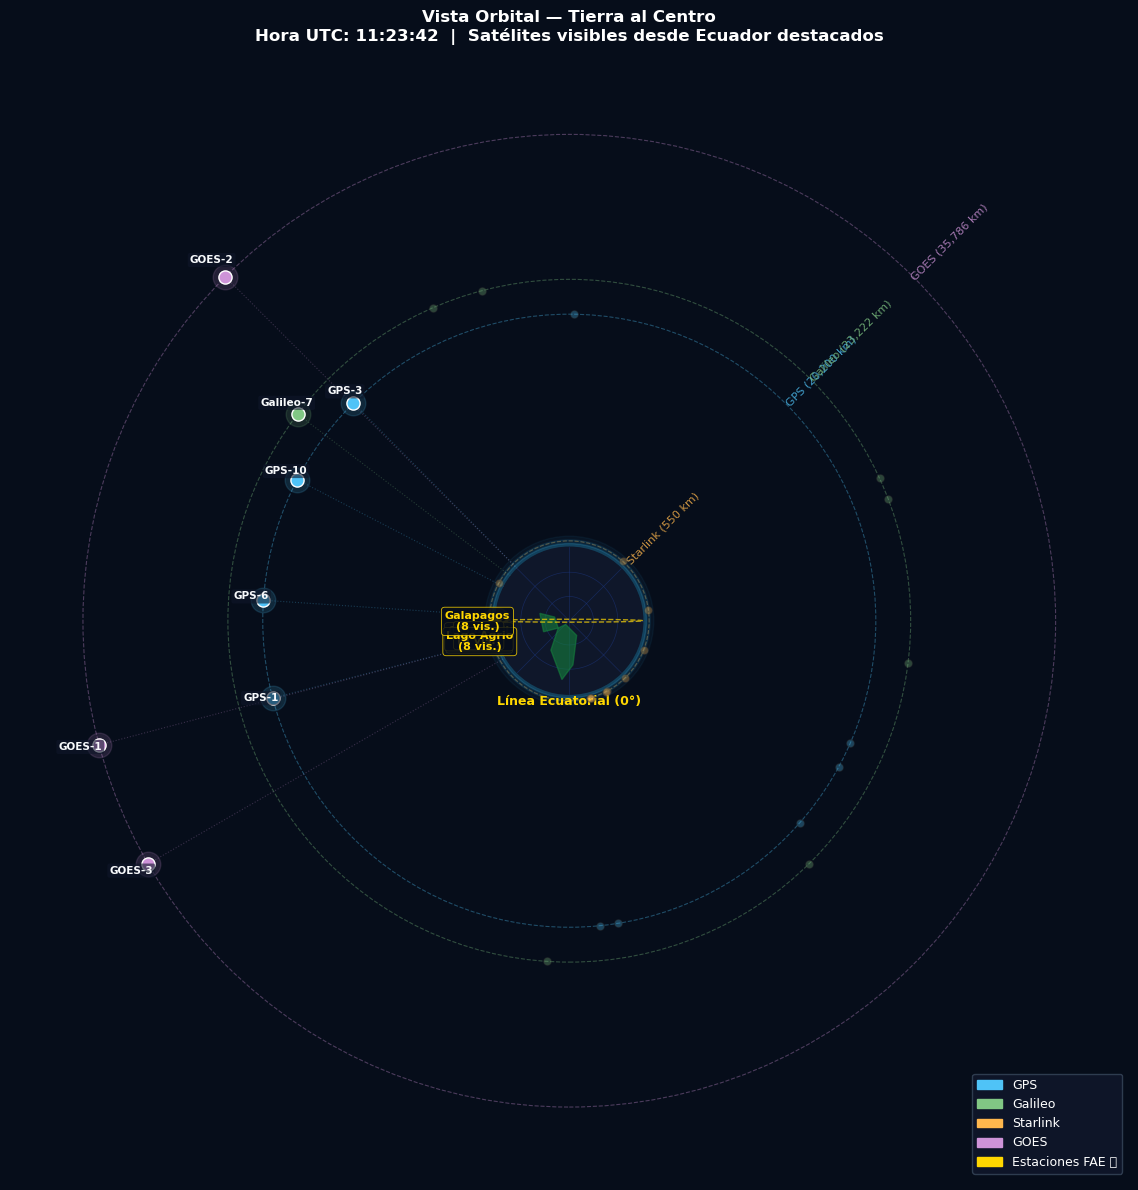

✅ Guardado con alta calidad (300 DPI): orbital_fae.png


In [5]:
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Configuración inicial ──
fig, ax = plt.subplots(figsize=(12, 12), facecolor='#060d1a')
ax.set_facecolor('#060d1a')
ax.set_aspect('equal')

RE_vis = 1.0  # Radio visual de la Tierra
scale = RE_vis / RE

# ── 1. ÓRBITAS DE REFERENCIA ──
orbitas = [
    ('Starlink', '#FFB74D', 550),
    ('GPS', '#4FC3F7', 20200),
    ('Galileo', '#81C784', 23222),
    ('GOES', '#CE93D8', 35786)
]

for nombre, color, alt in orbitas:
    r = (RE + alt) * scale
    circ = plt.Circle((0, 0), r, fill=False, color=color, lw=0.8, ls='--', alpha=0.35)
    ax.add_patch(circ)
    ax.text(r * 0.70, r * 0.70, f'{nombre} ({alt:,} km)', color=color, fontsize=8, alpha=0.8, rotation=45)

# ── 2. PLANETA TIERRA REALISTA Y ATMÓSFERA ──
# Resplandor atmosférico exterior (Atmospheric Glow)
for dr, a in zip([0.15, 0.10, 0.05], [0.05, 0.10, 0.18]):
    ax.add_patch(plt.Circle((0, 0), RE_vis + dr, color='#38bdf8', alpha=a, zorder=4))

# Cuerpo base de la Tierra
tierra = plt.Circle((0, 0), RE_vis, color='#0f172a', zorder=5) # Fondo oceánico oscuro
ax.add_patch(tierra)

# Red Geodésica (Líneas de Latitud/Longitud)
theta = np.linspace(0, 2 * np.pi, 200)
for r_grid in [0.33, 0.66]:
    ax.plot(r_grid * np.cos(theta), r_grid * np.sin(theta), color='#1e3a8a', lw=0.5, alpha=0.5, zorder=6)

for ang_deg in range(0, 360, 45):
    rad = math.radians(ang_deg)
    ax.plot([0, RE_vis * np.cos(rad)], [0, RE_vis * np.sin(rad)], color='#1e3a8a', lw=0.5, alpha=0.5, zorder=6)

# Silueta simplificada de las masas continentales (América / Ecuador al centro)
cont_sudamerica = plt.Polygon([
    (-0.15, -0.1), (-0.05, -0.05), (0.1, -0.2), 
    (0.05, -0.6), (-0.1, -0.8), (-0.25, -0.4)
], color='#15803d', alpha=0.6, zorder=7)

cont_centroamerica = plt.Polygon([
    (-0.4, 0.1), (-0.2, 0.05), (-0.15, -0.1), (-0.35, -0.15)
], color='#15803d', alpha=0.6, zorder=7)

ax.add_patch(cont_sudamerica)
ax.add_patch(cont_centroamerica)

# Línea del Ecuador (0°)
ax.plot(RE_vis * np.cos(theta), RE_vis * 0.02 * np.sin(theta),
        color='#FFD700', lw=1.0, ls='--', alpha=0.7, zorder=8)
ax.text(0, -RE_vis - 0.15, 'Línea Ecuatorial (0°)', color='#FFD700',
        fontsize=9, ha='center', fontweight='bold', zorder=8)

COLS = {'GPS': '#4FC3F7', 'Galileo': '#81C784', 'Starlink': '#FFB74D', 'GOES': '#CE93D8'}
# ── 3. SATÉLITES EN ÓRBITA ──
for s in satelites:
    sp = sat_ecef(s, ahora)
    lat, lon = ecef_ll(sp)
    r_vis = (RE + s['alt_km']) * scale
    ang = lon * math.pi / 180 - math.pi / 2
    px, py = r_vis * math.cos(ang), r_vis * math.sin(ang)
    
    vis_now = any(v['sat']['nombre'] == s['nombre'] for v in vis)
    sz = 90 if vis_now else 30
    alpha = 1.0 if vis_now else 0.3
    color = COLS.get(s['constelacion'], '#FFFFFF')
    
    # Enlace visual al origen (Tierra)
    if vis_now:
        ax.plot([0, px], [0, py], color=color, alpha=0.25, lw=0.8, ls=':', zorder=3)
        ax.scatter(px, py, s=sz * 3.5, color=color, alpha=0.15, zorder=9)
        
    ax.scatter(px, py, s=sz, color=color,
               edgecolors='white' if vis_now else '#333333',
               lw=1.0, alpha=alpha, zorder=10)
    
    if vis_now:
        ax.text(px * 1.04, py * 1.04, s['nombre'],
                color='#F8FAFC', fontsize=7.5, fontweight='bold', ha='center',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#0F172A', alpha=0.6, edgecolor='none'),
                zorder=11)

# ── 4. ESTACIONES Y ETIQUETAS MEJORADAS ──
for e in estaciones:
    ang = e['lon'] * math.pi / 180 - math.pi / 2
    # Posicionar la estación exactamente en la superficie terrestre
    px_est, py_est = RE_vis * math.cos(ang), RE_vis * math.sin(ang)
    nv = sum(1 for v in vis if v['est']['nombre'] == e['nombre'])
    
    # Halo brillante de la estación
    ax.scatter(px_est, py_est, s=400, color='#FFD700', alpha=0.15, zorder=12)
    # Marcador Estrella
    ax.scatter(px_est, py_est, s=180, color='#FFD700', marker='*',
               edgecolors='#060d1a', lw=1.0, zorder=13)
    
    # Cálculo del desplazamiento adaptativo de etiquetas (evita solapamientos)
    offset_r = 1.25  # Empuja la etiqueta hacia afuera de la corteza terrestre
    tx, ty = RE_vis * offset_r * math.cos(ang), RE_vis * offset_r * math.sin(ang)
    
    # Línea conector de la estación a su etiqueta exterior
    ax.plot([px_est, tx * 0.95], [py_est, ty * 0.95], color='#FFD700', lw=0.6, alpha=0.5, zorder=12)
    
    # Formato de texto del nombre
    nombre_limpio = e['nombre'].replace('Estación ', '')
    
    ax.text(tx, ty, f"{nombre_limpio}\n({nv} vis.)",
            color='#FFD700', fontsize=8, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#060d1a', edgecolor='#FFD700', alpha=0.85, lw=0.6),
            zorder=14)

# ── 5. LEYENDA Y ENCABEZADOS ──
patches = [mpatches.Patch(color=c, label=cn) for cn, c in COLS.items()]
patches.append(mpatches.Patch(color='#FFD700', label='Estaciones FAE ⭐'))

ax.legend(handles=patches, loc='lower right', facecolor='#0f172a',
          edgecolor='#334155', labelcolor='white', fontsize=9, framealpha=0.9)

maxr = (RE + 35786) * scale * 1.15
ax.set_xlim(-maxr, maxr)
ax.set_ylim(-maxr, maxr)
ax.axis('off')

ax.set_title(f'Vista Orbital — Tierra al Centro\nHora UTC: {ahora.strftime("%H:%M:%S")}  |  Satélites visibles desde Ecuador destacados',
             color='white', fontsize=12, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('orbital_fae.png', dpi=300, bbox_inches='tight', facecolor='#060d1a')
plt.show()
print('✅ Guardado con alta calidad (300 DPI): orbital_fae.png')

## 7. Heatmap de visibilidad por estación

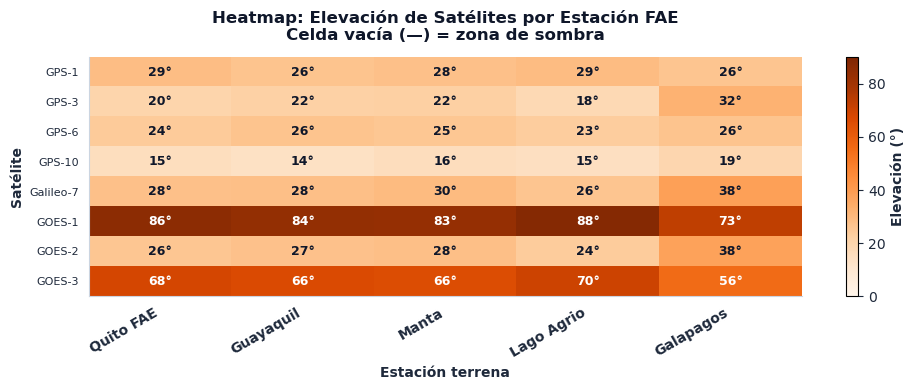

✅ Guardado con paleta en tonos naranja: heatmap_fae.png


In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. DEFINICIÓN DE DICCIONARIOS Y COLORES
COLS = {
    'GPS': '#1f77b4',
    'Galileo': '#2ca02c',
    'Starlink': '#ff7f0e',
    'GOES': '#9467bd'
}

# Datos de respaldo (se usan si no se han definido previamente)
if 'satelites' not in locals():
    satelites = [
        {'nombre': 'GPS-01', 'constelacion': 'GPS'},
        {'nombre': 'GPS-02', 'constelacion': 'GPS'},
        {'nombre': 'Galileo-01', 'constelacion': 'Galileo'},
        {'nombre': 'Starlink-101', 'constelacion': 'Starlink'},
        {'nombre': 'GOES-16', 'constelacion': 'GOES'}
    ]

if 'estaciones' not in locals():
    estaciones = [
        {'nombre': 'Quito FAE'},
        {'nombre': 'Guayaquil FAE'},
        {'nombre': 'Manta FAE'},
        {'nombre': 'Lago Agrio FAE'},
        {'nombre': 'Galápagos FAE'}
    ]

if 'vis' not in locals():
    vis = [
        {'sat': {'nombre': 'GPS-01'}, 'est': {'nombre': 'Quito FAE'}, 'el': 45},
        {'sat': {'nombre': 'GPS-01'}, 'est': {'nombre': 'Guayaquil FAE'}, 'el': 52},
        {'sat': {'nombre': 'GPS-02'}, 'est': {'nombre': 'Manta FAE'}, 'el': 88},
        {'sat': {'nombre': 'Galileo-01'}, 'est': {'nombre': 'Galápagos FAE'}, 'el': 35},
        {'sat': {'nombre': 'Starlink-101'}, 'est': {'nombre': 'Manta FAE'}, 'el': 78},
        {'sat': {'nombre': 'GOES-16'}, 'est': {'nombre': 'Quito FAE'}, 'el': 65},
        {'sat': {'nombre': 'GOES-16'}, 'est': {'nombre': 'Manta FAE'}, 'el': 68},
    ]

# 2. CONSTRUIR MATRIZ DE ELEVACIÓN MÁXIMA
sat_names = [s['nombre'] for s in satelites]
est_names = [e['nombre'] for e in estaciones]
mat = np.full((len(satelites), len(estaciones)), np.nan)

for v in vis:
    i = sat_names.index(v['sat']['nombre'])
    j = est_names.index(v['est']['nombre'])
    mat[i, j] = v['el']

# Filtrar solo satélites con visibilidad
mask = ~np.all(np.isnan(mat), axis=1)
mat_f = mat[mask]
sat_f = [s for s, m in zip(sat_names, mask) if m]

if len(sat_f) == 0:
    print('⚠️ Sin visibilidades para el heatmap. Revisa tus datos.')
else:
    fig, ax = plt.subplots(figsize=(10, max(4, len(sat_f) * 0.4)))
    
    # Fondo blanco puro
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    mat_plot = np.where(np.isnan(mat_f), 0, mat_f)
    
    # Cambiado a 'Oranges' (gradiente cálido de blanco/crema a naranja intenso)
    im = ax.imshow(mat_plot, cmap='Oranges', aspect='auto', vmin=0, vmax=90)

    ax.set_xticks(range(len(est_names)))
    ax.set_yticks(range(len(sat_f)))
    
    ax.set_xticklabels(est_names, rotation=30, ha='right', color='#1e293b', fontsize=10, fontweight='bold')
    ax.set_yticklabels(sat_f, color='#1e293b', fontsize=8)

    # Añadir valores dentro de cada celda con contraste dinámico
    for i in range(len(sat_f)):
        for j in range(len(est_names)):
            val = mat_f[i, j]
            if not np.isnan(val):
                # Para elevaciones altas (naranja oscuro), texto blanco; si es bajo, texto oscuro
                text_color = 'white' if val > 55 else '#0f172a'
                ax.text(j, i, f'{val:.0f}°', ha='center', va='center',
                        fontsize=9, fontweight='bold', color=text_color)
            else:
                ax.text(j, i, '—', ha='center', va='center',
                        fontsize=9, color='#94a3b8')

    # Barra de color
    cbar = plt.colorbar(im, ax=ax)
    cbar.ax.tick_params(colors='#1e293b')
    cbar.set_label('Elevación (°)', color='#1e293b', fontweight='bold')

    # Títulos y ejes
    ax.set_title('Heatmap: Elevación de Satélites por Estación FAE\nCelda vacía (—) = zona de sombra',
                 color='#0f172a', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Estación terrena', color='#1e293b', fontweight='bold')
    ax.set_ylabel('Satélite', color='#1e293b', fontweight='bold')

    # Bordes limpios
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cbd5e1')
    ax.spines['bottom'].set_color('#cbd5e1')

    plt.tight_layout()
    plt.savefig('heatmap_fae.png', dpi=300, bbox_inches='tight', facecolor='white')
    plt.show()
    print('✅ Guardado con paleta en tonos naranja: heatmap_fae.png')

In [7]:
from datetime import timedelta

# ── 1. Buscar el instante óptimo dentro de los próximos 60 minutos ──
DURACION_MINUTOS = 60
PASO_MINUTOS = 1
EL_MIN_TARGET = 10  # Elevación mínima deseada

tiempo_encontrado = None
max_vis_starlink = 0
mejor_momento = ahora

print("🔍 Buscando pasadas de Starlink en los próximos 60 minutos...")

for m in range(0, DURACION_MINUTOS, PASO_MINUTOS):
    t_eval = ahora + timedelta(minutes=m)
    conteo_starlink = 0
    
    for s in satelites:
        if 'starlink' in s['constelacion'].lower():
            sp = sat_ecef(s, t_eval)
            for e in estaciones:
                ep = est_ecef(e)
                el = elevacion(sp, ep)
                if el >= EL_MIN_TARGET:
                    conteo_starlink += 1
    
    # Guardar el momento con mayor cantidad de satélites Starlink visibles
    if conteo_starlink > max_vis_starlink:
        max_vis_starlink = conteo_starlink
        mejor_momento = t_eval

# ── 2. Decidir el momento a graficar ──
if max_vis_starlink > 0:
    ahora = mejor_momento
    print(f"✅ ¡Visibilidad encontrada! Ajustando simulación a UTC: {ahora.strftime('%H:%M:%S')}")
    print(f"   └─ Conexiones Starlink encontradas: {max_vis_starlink}")
else:
    print("⚠️ No se encontraron pasadas de Starlink ≥ 10° en los próximos 60 min.")
    print("   Se mantendrá el tiempo actual o puedes incrementar el rango a 120 min.")

# ── 3. Calcular la lista de visibilidad para el instante seleccionado ──
EL_MIN = 10
vis = []

for s in satelites:
    sp = sat_ecef(s, ahora)
    for e in estaciones:
        ep = est_ecef(e)
        el = elevacion(sp, ep)
        if el >= EL_MIN:
            vis.append({'sat': s, 'est': e, 'el': round(el, 1)})

print(f"\nResumen para {ahora.strftime('%H:%M:%S')} UTC:")
print(f" • Aristas totales: {len(vis)}")
print(f" • Satélites visibles: {len(set(v['sat']['nombre'] for v in vis))}")

🔍 Buscando pasadas de Starlink en los próximos 60 minutos...
✅ ¡Visibilidad encontrada! Ajustando simulación a UTC: 11:26:42
   └─ Conexiones Starlink encontradas: 2

Resumen para 11:26:42 UTC:
 • Aristas totales: 42
 • Satélites visibles: 9


🔍 Buscando pasadas de Starlink en los próximos 60 minutos...
✅ ¡Visibilidad encontrada! Tiempo ajustado a UTC: 11:26:32
   └─ Conexiones Starlink detectadas: 2

Resumen final (11:26:32 UTC):
 • Aristas totales: 42
 • Satélites visibles: 9



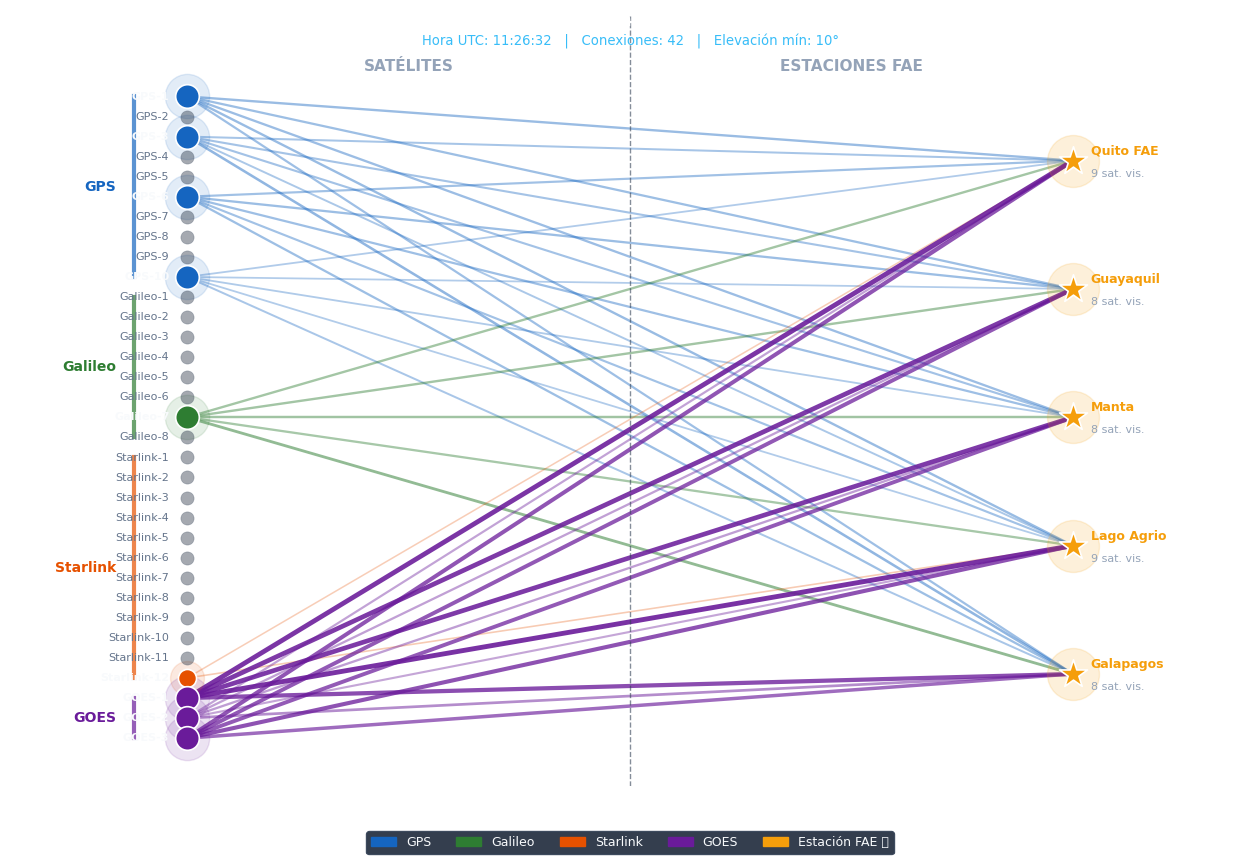

✅ Gráfico renderizado y guardado a 300 DPI: grafo_bipartito_fae.png


In [9]:
from datetime import datetime, timezone, timedelta
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── 1. BUSCAR INSTANTE DE MAYOR VISIBILIDAD DE STARLINK (Próximos 60 min) ──
ahora = datetime.now(timezone.utc)
DURACION_MINUTOS = 60
PASO_MINUTOS = 1
EL_MIN_TARGET = 10

max_vis_starlink = 0
mejor_momento = ahora

print("🔍 Buscando pasadas de Starlink en los próximos 60 minutos...")

for m in range(0, DURACION_MINUTOS, PASO_MINUTOS):
    t_eval = ahora + timedelta(minutes=m)
    conteo_starlink = 0
    
    for s in satelites:
        if 'starlink' in s['constelacion'].lower():
            sp = sat_ecef(s, t_eval)
            for e in estaciones:
                ep = est_ecef(e)
                el = elevacion(sp, ep)
                if el >= EL_MIN_TARGET:
                    conteo_starlink += 1
    
    if conteo_starlink > max_vis_starlink:
        max_vis_starlink = conteo_starlink
        mejor_momento = t_eval

# Seleccionar el tiempo a simular
if max_vis_starlink > 0:
    ahora = mejor_momento
    print(f"✅ ¡Visibilidad encontrada! Tiempo ajustado a UTC: {ahora.strftime('%H:%M:%S')}")
    print(f"   └─ Conexiones Starlink detectadas: {max_vis_starlink}")
else:
    print("⚠️ No se encontraron pasadas de Starlink ≥ 10° en 60 min. Se graficará el instante actual.")

# ── 2. CALCULAR LISTA DE VISIBILIDAD (vis) ──
EL_MIN = 10
vis = []

for s in satelites:
    sp = sat_ecef(s, ahora)
    for e in estaciones:
        ep = est_ecef(e)
        el = elevacion(sp, ep)
        if el >= EL_MIN:
            vis.append({'sat': s, 'est': e, 'el': round(el, 1)})

print(f"\nResumen final ({ahora.strftime('%H:%M:%S')} UTC):")
print(f" • Aristas totales: {len(vis)}")
print(f" • Satélites visibles: {len(set(v['sat']['nombre'] for v in vis))}\n")

# ── 3. VISUALIZACIÓN DEL GRAFO BIPARTITO ──

fig, ax = plt.subplots(figsize=(16, 10), facecolor='white')
ax.set_facecolor('white')

COLS = {'GPS': '#1565C0', 'Galileo': '#2E7D32', 'Starlink': '#E65100', 'GOES': '#6A1B9A'}

# Layout
n_sat = len(satelites)
n_est = len(estaciones)

pos_sat = {
    s['nombre']: (-1, 1 - 2 * i / max(1, n_sat - 1)) 
    for i, s in enumerate(satelites)
}
pos_est = {
    e['nombre']: (1, 0.8 - 1.6 * i / max(1, n_est - 1)) 
    for i, e in enumerate(estaciones)
}

# Grado de nodos
grado_sat = {s['nombre']: 0 for s in satelites}
grado_est = {e['nombre']: 0 for e in estaciones}

for v in vis:
    grado_sat[v['sat']['nombre']] += 1
    grado_est[v['est']['nombre']] += 1

# Dibujar aristas
elevaciones = [v['el'] for v in vis]
max_el = max(elevaciones) if elevaciones else 1.0

for v in vis:
    sn, en = v['sat']['nombre'], v['est']['nombre']
    sx, sy = pos_sat[sn]
    ex, ey = pos_est[en]
    
    norm_el = v['el'] / max_el if max_el > 0 else 0
    color = COLS.get(v['sat']['constelacion'], '#FFFFFF')
    
    ax.plot(
        [sx, ex], [sy, ey],
        color=color,
        alpha=0.20 + 0.70 * norm_el,
        lw=0.8 + 2.7 * norm_el,
        zorder=1
    )

# Agrupación por constelación
grupos = {}
for s in satelites:
    grupos.setdefault(s['constelacion'], []).append(s)

for cn, grp in grupos.items():
    ys = [pos_sat[s['nombre']][1] for s in grp]
    yc = sum(ys) / len(ys)
    color = COLS.get(cn, '#FFFFFF')
    
    ax.plot([-1.12, -1.12], [min(ys), max(ys)], color=color, lw=3, alpha=0.7, zorder=1)
    ax.text(-1.16, yc, cn, color=color, fontsize=10, fontweight='bold', va='center', ha='right')

# Dibujar satélites
for s in satelites:
    sn = s['nombre']
    x, y = pos_sat[sn]
    g = grado_sat[sn]
    vis_now = g > 0
    r = 90 + g * 40
    color = COLS.get(s['constelacion'], '#FFFFFF')
    
    if vis_now:
        ax.scatter(x, y, s=r*3.5, color=color, alpha=0.12, zorder=2)
        
    ax.scatter(
        x, y, s=r, 
        color=color if vis_now else '#1E293B',
        alpha=1.0 if vis_now else 0.4,
        edgecolors='white' if vis_now else '#475569',
        linewidths=1.2 if vis_now else 0.5, 
        zorder=3
    )
    
    ax.text(
        x - 0.04, y, sn, 
        color='#F8FAFC' if vis_now else '#64748B', 
        fontsize=8, 
        fontweight='bold' if vis_now else 'normal',
        va='center', ha='right'
    )

# Dibujar estaciones
for e in estaciones:
    en = e['nombre']
    x, y = pos_est[en]
    g = grado_est[en]
    vis_now = g > 0
    
    if vis_now:
        ax.scatter(x, y, s=1400, color='#F59E0B', alpha=0.15, zorder=2)
        
    ax.scatter(
        x, y, s=450, 
        color='#F59E0B' if vis_now else '#334155',
        marker='*', 
        edgecolors='#FFF' if vis_now else '#475569',
        linewidths=1.2 if vis_now else 0.5,
        alpha=1.0 if vis_now else 0.5, 
        zorder=4
    )
    
    ax.text(
        x + 0.04, y + 0.03, en, 
        color='#F59E0B' if vis_now else '#64748B',
        fontsize=9, fontweight='bold' if vis_now else 'normal', 
        va='center', ha='left'
    )
    ax.text(
        x + 0.04, y - 0.04, f'{g} sat. vis.', 
        color='#94A3B8' if vis_now else '#475569', 
        fontsize=8, va='center', ha='left'
    )

# Divisor y Títulos
ax.axvline(x=0, color='#334155', lw=1, ls='--', alpha=0.6)
ax.text(-0.5, 1.08, 'SATÉLITES', color='#94A3B8', fontsize=11, fontweight='bold', ha='center')
ax.text(0.5, 1.08, 'ESTACIONES FAE', color='#94A3B8', fontsize=11, fontweight='bold', ha='center')

# Leyenda (Corregida sin el argumento inválido boxcoords)
patches = [mpatches.Patch(color=c, label=cn) for cn, c in COLS.items()]
patches.append(mpatches.Patch(color='#F59E0B', label='Estación FAE ⭐'))

legend = ax.legend(
    handles=patches, 
    loc='upper center', 
    bbox_to_anchor=(0.5, -0.05),
    ncol=5,
    facecolor='#1E293B', 
    edgecolor='#334155', 
    labelcolor='#F8FAFC', 
    fontsize=9, 
    framealpha=0.9
)

ax.text(
    0, 1.22, 'Grafo Bipartito: Visibilidad Satélite ↔ Estación FAE',
    color='white', fontsize=14, fontweight='bold', ha='center'
)
ax.text(
    0, 1.16, 
    f'Hora UTC: {ahora.strftime("%H:%M:%S")}   |   Conexiones: {len(vis)}   |   Elevación mín: {EL_MIN}°',
    color='#38BDF8', fontsize=9.5, ha='center'
)

# Configuración de ejes y guardado
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.15, 1.25)
ax.axis('off')

plt.savefig('grafo_bipartito_fae.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print('✅ Gráfico renderizado y guardado a 300 DPI: grafo_bipartito_fae.png')